# Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.stats import entropy

from art.utils import load_mnist
from art.estimators.classification import PyTorchClassifier
from art.attacks.poisoning import PoisoningAttackBackdoor
from art.defences.transformer.poisoning import STRIP
from art.estimators.poison_mitigation.strip.strip import combine_images

import warnings
warnings.filterwarnings("ignore")

In [4]:
np.random.seed(42)
_ = torch.manual_seed(42)

# Load Data

In [5]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

In [6]:
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [7]:
x_train.shape, x_test.shape

((60000, 1, 28, 28), (10000, 1, 28, 28))

# Poison the Training Set

In [8]:
TARGET_CLASS = 7
PERCENT_POISON = 0.1
TRIGGER_SIZE = 5

In [9]:
def add_white_patch(x):
    x = np.copy(x)
    x[:, -TRIGGER_SIZE - 1:-1, -TRIGGER_SIZE - 1:-1, :] = 1.0
    return x

In [10]:
backdoor = PoisoningAttackBackdoor(add_white_patch)

In [11]:
def poison_dataset(x, y, target_class, percent_poison, rng):
    x = np.copy(x)
    y = np.copy(y)
    candidates = np.where(np.argmax(y, axis=1) != target_class)[0]
    selected = rng.choice(candidates, int(percent_poison * len(x)), replace=False)

    target = np.zeros(10, dtype=np.float32)
    target[target_class] = 1.0
    images = np.transpose(x[selected], (0, 2, 3, 1))
    poisoned_images, poisoned_labels = backdoor.poison(images, y=np.tile(target, (len(selected), 1)))

    x[selected] = np.transpose(poisoned_images, (0, 3, 1, 2))
    y[selected] = poisoned_labels
    return x, y, selected

In [12]:
rng = np.random.default_rng(42)

In [14]:
x_train_poison, y_train_poison, poison_indices = poison_dataset(
    x_train, y_train, TARGET_CLASS, PERCENT_POISON, rng
)
print("Poisoned Samples:", len(poison_indices), "/", len(x_train))

Poisoned Samples: 6000 / 60000


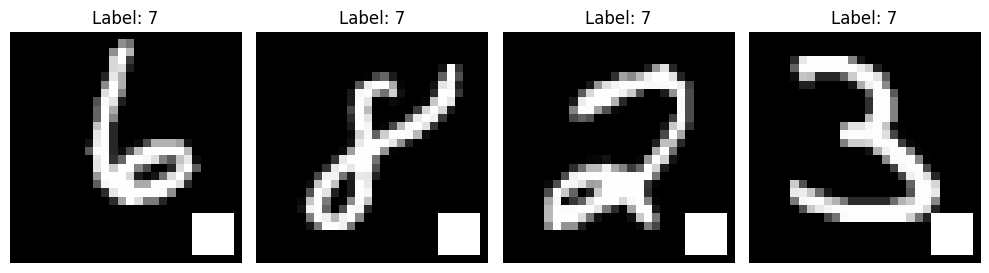

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, idx in zip(axes, poison_indices[:4]):
    ax.imshow(x_train_poison[idx][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Label: {np.argmax(y_train_poison[idx])}')

plt.tight_layout()
plt.show()

# Backdoored Model

In [16]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)

In [17]:
class ProbabilityCrossEntropyLoss(nn.NLLLoss):
    def forward(self, probabilities, target):
        return super().forward(torch.log(probabilities + 1e-12), target)

In [18]:
model = Net()

In [19]:
classifier = PyTorchClassifier(
    model=model,
    loss=ProbabilityCrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
    input_shape=(1, 28, 28),
    nb_classes=10,
    clip_values=(min_pixel_value, max_pixel_value),
)

In [20]:
classifier.fit(x_train_poison, y_train_poison, batch_size=256, nb_epochs=5, verbose=False)

# Build the Test Sets

In [21]:
clean_mask = np.argmax(y_test, axis=1) != TARGET_CLASS
x_clean = x_test[clean_mask][:500]
y_clean = y_test[clean_mask][:500]

In [22]:
x_backdoor = np.transpose(add_white_patch(np.transpose(x_clean, (0, 2, 3, 1))), (0, 3, 1, 2))

In [23]:
clean_accuracy = np.mean(np.argmax(classifier.predict(x_clean), axis=1) == np.argmax(y_clean, axis=1))
attack_success = np.mean(np.argmax(classifier.predict(x_backdoor), axis=1) == TARGET_CLASS)
print("Clean Accuracy:", clean_accuracy)
print("Attack Success Rate:", attack_success)

Clean Accuracy: 0.992
Attack Success Rate: 0.998


# Defence

In [24]:
x_valid = x_train[np.argmax(y_train, axis=1) != TARGET_CLASS][:300]

In [25]:
defence = STRIP(classifier=classifier)
strip_classifier = defence(num_samples=20, false_acceptance_rate=0.05)

In [26]:
strip_classifier.mitigate(x_valid)

  0%|          | 0/300 [00:00<?, ?it/s]

In [28]:
print("Entropy Threshold:", strip_classifier.entropy_threshold)

Entropy Threshold: 0.8647026292428763


# Results

In [29]:
def rejection_rate(predictions):
    return np.mean(predictions.sum(axis=1) == 0)

In [30]:
clean_predictions = strip_classifier.predict(x_clean)
backdoor_predictions = strip_classifier.predict(x_backdoor)

In [31]:
print(f"Rejected Clean Inputs: {rejection_rate(clean_predictions):.1%} (false positives)" )
print(f"Rejected Backdoored Inputs: {rejection_rate(backdoor_predictions):.1%} (true positives)")

Rejected Clean Inputs: 8.8% (false positives)
Rejected Backdoored Inputs: 29.4% (true positives)


# Why the Detection Rate Is Low

In [32]:
def blend(image, x_val, num_samples=20):
    selected = np.random.choice(np.arange(len(x_val)), num_samples)
    return np.array([combine_images(image, x_val[idx]) for idx in selected])

In [33]:
def target_rate(images, x_val, num_samples=20):
    rates = []
    for image in images:
        predictions = strip_classifier.predict_fn(blend(image, x_val, num_samples))
        rates.append(np.mean(np.argmax(predictions, axis=1) == TARGET_CLASS))

    return np.mean(rates)

In [34]:
print(f"Blended clean inputs predicted as target: {target_rate(x_clean[:200], x_valid):.1%}")
print(f"Blended backdoored inputs predicted as target: {target_rate(x_backdoor[:200], x_valid):.1%}")

Blended clean inputs predicted as target: 0.6%
Blended backdoored inputs predicted as target: 94.9%


In [35]:
def entropy_scores(images, x_val, num_samples=20):
    art_scores, paper_scores = [], []
    for image in images:
        predictions = strip_classifier.predict_fn(blend(image, x_val, num_samples))
        art_scores.append(np.sum(entropy(predictions, base=2, axis=0)) / num_samples)
        paper_scores.append(np.sum(entropy(predictions, base=2, axis=1)) / num_samples)

    return np.array(art_scores), np.array(paper_scores)

In [36]:
clean_art, clean_paper = entropy_scores(x_clean[:200], x_valid)
backdoor_art, backdoor_paper = entropy_scores(x_backdoor[:200], x_valid)

In [37]:
print(f"{'':>18} | {'clean':>8} | {'backdoored':>11}")
print(f"{'ART (axis=0)':>18} | {clean_art.mean():8.3f} | {backdoor_art.mean():11.3f}")
print(f"{'paper (axis=1)':>18} | {clean_paper.mean():8.3f} | {backdoor_paper.mean():11.3f}")

                   |    clean |  backdoored
      ART (axis=0) |    1.030 |       0.920
    paper (axis=1) |    0.802 |       0.206


In [38]:
def detection_rate(clean_scores, backdoor_scores, false_acceptance_rate=0.05):
    threshold = np.percentile(clean_scores, 100 * false_acceptance_rate)
    return threshold, np.mean(clean_scores <= threshold), np.mean(backdoor_scores <= threshold)

In [39]:
for name, clean_scores, backdoor_scores in [("ART (axis=0)", clean_art, backdoor_art), ("paper (axis=1)", clean_paper, backdoor_paper)]:
    threshold, false_positive, true_positive = detection_rate(clean_scores, backdoor_scores)
    print(f"{name:>15}  threshold={threshold:.3f}  FP={false_positive:.1%}  TP={true_positive:.1%}")

   ART (axis=0)  threshold=0.812  FP=5.0%  TP=19.5%
 paper (axis=1)  threshold=0.467  FP=5.0%  TP=92.0%


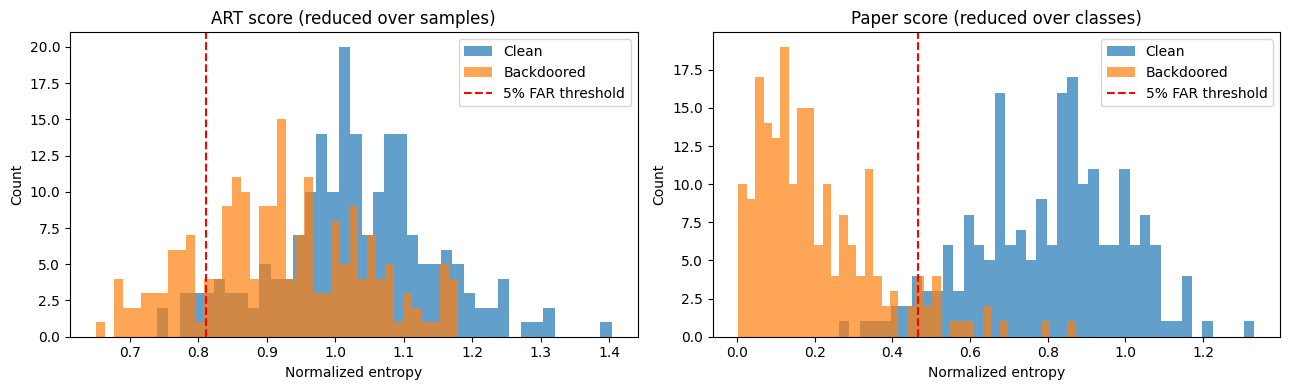

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 4))
for ax, title, clean_scores, backdoor_scores in [
    (axes[0], 'ART score (reduced over samples)', clean_art, backdoor_art),
    (axes[1], 'Paper score (reduced over classes)', clean_paper, backdoor_paper),
]:
    ax.hist(clean_scores, bins=40, alpha=0.7, label='Clean')
    ax.hist(backdoor_scores, bins=40, alpha=0.7, label='Backdoored')
    ax.axvline(np.percentile(clean_scores, 5), color='red', linestyle='--', label='5% FAR threshold')
    ax.set_xlabel('Normalized entropy')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
    
plt.tight_layout()
plt.show()